#Student Performance Analysis Using Pandas

##Project Overview
This project analyzes student academic performance using Python and Pandas.

The dataset contained:
- Missing values
- Duplicate records
- Invalid text values

The data was cleaned and analyzed to identify:
- Student averages
- Grades
- Subject performance
- Best subjects
- Top-performing students

#Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#Load Dataset

In [ ]:
students_df = pd.read_csv("student-marks-analyzer\\data\\data.csv")

#Explore Dataset

In [4]:
students_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     100 non-null    str    
 1   math     97 non-null     str    
 2   science  99 non-null     float64
 3   english  100 non-null    str    
dtypes: float64(1), str(3)
memory usage: 3.3 KB


---
#Data Cleaning
---


In [5]:
students_df.isnull().sum()

name       0
math       3
science    1
english    0
dtype: int64

##Delete duplicate value

In [6]:
students_df.duplicated().sum()

students_df[students_df.duplicated()]

students_df = students_df.drop_duplicates()

students_df.duplicated().sum()

students_df = students_df.reset_index(drop=True)


##Replace Invalid Text Values

In [7]:
students_df = students_df.replace(['ABSENT', 'ERROR', 'NULL', 'N/A'], pd.NA)

##Convert Columns to Numeric

In [8]:
columns = ['math', 'science', 'english']

for col in columns:
    students_df[col] = pd.to_numeric(students_df[col], errors='coerce')

students_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     96 non-null     str    
 1   math     92 non-null     float64
 2   science  95 non-null     float64
 3   english  95 non-null     float64
dtypes: float64(3), str(1)
memory usage: 3.1 KB


##Handle Missing Values

In [9]:
students_df = students_df.dropna()

students_df = students_df.reset_index(drop=True)


In [10]:
students_df.isnull().sum()

name       0
math       0
science    0
english    0
dtype: int64

In [11]:
clean_students_df = students_df.copy()

clean_students_df

,name,math,science,english
0,John,78.0,85.0,90.0
1,Sara,92.0,88.0,95.0
2,Mike,60.0,70.0,65.0
3,Nina,45.0,50.0,40.0
4,Alex,88.0,76.0,85.0
...,...,...,...,...
85,Audrey,82.0,85.0,81.0
86,Caleb,74.0,77.0,72.0
87,Brooklyn,89.0,92.0,88.0
88,Josiah,58.0,61.0,55.0


---
#Analysis Data
---

##Average Mark of the Student

In [12]:
clean_students_df['average'] = clean_students_df[['math', 'science', 'english']].mean(axis=1)

clean_students_df

,name,math,science,english,average
0,John,78.0,85.0,90.0,84.333333
1,Sara,92.0,88.0,95.0,91.666667
2,Mike,60.0,70.0,65.0,65.000000
3,Nina,45.0,50.0,40.0,45.000000
4,Alex,88.0,76.0,85.0,83.000000
...,...,...,...,...,...
85,Audrey,82.0,85.0,81.0,82.666667
86,Caleb,74.0,77.0,72.0,74.333333
87,Brooklyn,89.0,92.0,88.0,89.666667
88,Josiah,58.0,61.0,55.0,58.000000


##Average Mark of the Subjects

In [13]:
subject_average = clean_students_df[['math', 'science', 'english']].mean()

print(subject_average)


math       76.255556
science    77.944444
english    76.311111
dtype: float64


##Grade Systems

In [14]:
def grade(avg):
    if avg >= 85:
        return "A"
    elif avg >= 75:
        return "B"
    elif avg >= 65:
        return "C"
    else:
        return "F"
    
clean_students_df['grade'] = clean_students_df['average'].apply(grade)

clean_students_df


,name,math,science,english,average,grade
0,John,78.0,85.0,90.0,84.333333,B
1,Sara,92.0,88.0,95.0,91.666667,A
2,Mike,60.0,70.0,65.0,65.000000,C
3,Nina,45.0,50.0,40.0,45.000000,F
4,Alex,88.0,76.0,85.0,83.000000,B
...,...,...,...,...,...,...
85,Audrey,82.0,85.0,81.0,82.666667,B
86,Caleb,74.0,77.0,72.0,74.333333,C
87,Brooklyn,89.0,92.0,88.0,89.666667,A
88,Josiah,58.0,61.0,55.0,58.000000,F


##Performance Analysis For Each Subject

In [15]:
average_math_score = clean_students_df['math'].mean()
average_science_score = clean_students_df['science'].mean()
average_english_score = clean_students_df['english'].mean()

def check_performance(score, avg_mark):
    if score > avg_mark:
        return "Above Average"
    else:
        return "Below Average"

clean_students_df['math_performance'] = clean_students_df['math'].apply(lambda x: check_performance(x, average_math_score))
clean_students_df['english_performane'] = clean_students_df['english'].apply(lambda x: check_performance(x, average_english_score))
clean_students_df['science_performance'] = clean_students_df['science'].apply(lambda x: check_performance(x, average_science_score))

print(clean_students_df['math_performance'].value_counts())
print('--------------------------')
print(clean_students_df['science_performance'].value_counts())
print('--------------------------')
print(clean_students_df['english_performane'].value_counts())

math_performance
Above Average    52
Below Average    38
Name: count, dtype: int64
--------------------------
science_performance
Above Average    52
Below Average    38
Name: count, dtype: int64
--------------------------
english_performane
Above Average    53
Below Average    37
Name: count, dtype: int64


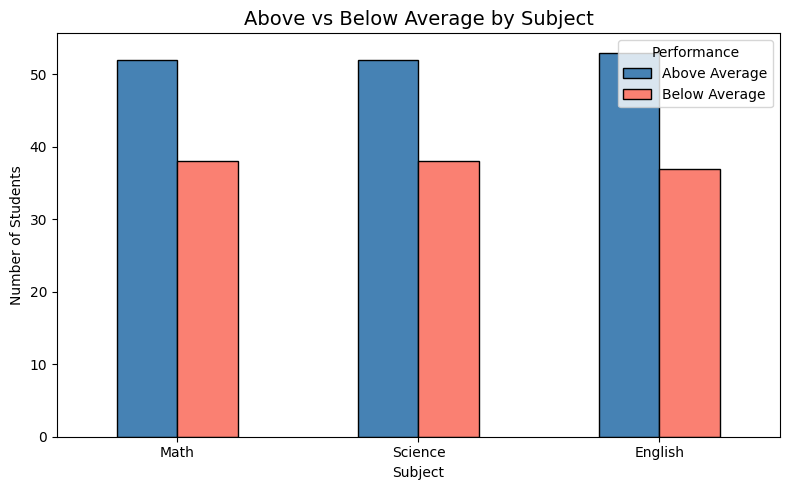

In [33]:
performance_dataframe = pd.DataFrame({
    'Above Average' : [
        (clean_students_df['math_performance'] == 'Above Average').sum(),
        (clean_students_df['science_performance'] == 'Above Average').sum(),
        (clean_students_df['english_performane'] == 'Above Average').sum()
    ],
    'Below Average' : [
        (clean_students_df['math_performance'] == 'Below Average').sum(),
        (clean_students_df['science_performance'] == 'Below Average').sum(),
        (clean_students_df['english_performane'] == 'Below Average').sum()
    ]
}, index=['Math', 'Science', 'English'])

performance_dataframe.plot(kind='bar',
                           figsize=(8, 5),
                           edgecolor='black',
                           color=['steelblue', 'salmon'])

plt.title("Above vs Below Average by Subject", fontsize=14)
plt.xlabel('Subject')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.legend(title='Performance')
plt.tight_layout()

plt.show()

##Find Best Subject

In [16]:
clean_students_df['best_subject'] = clean_students_df[['math', 'science', 'english']].idxmax(axis=1)

clean_students_df['best_subject'].value_counts()

best_subject
science    66
english    22
math        2
Name: count, dtype: int64

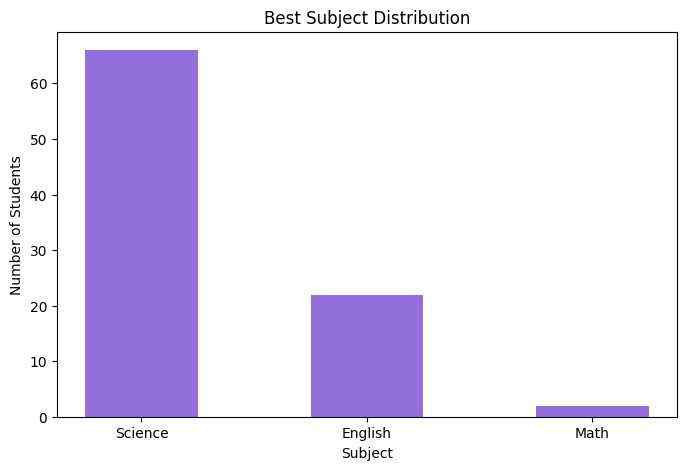

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(
    ['Science', 'English', 'Math'],
    clean_students_df['best_subject'].value_counts(),
    color = 'mediumpurple',
    width=0.5
)

plt.title('Best Subject Distribution')
plt.xlabel('Subject')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)

plt.show()

##Grade Distribution

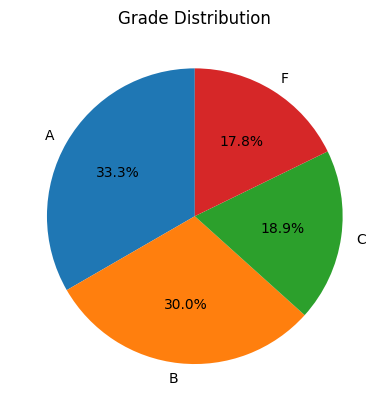

In [34]:
grade_count = clean_students_df['grade'].value_counts()

grade_count.plot(kind="pie",
                 autopct="%1.1f%%",
                 startangle=90)
plt.title("Grade Distribution")
plt.show()


##Top 10 Students

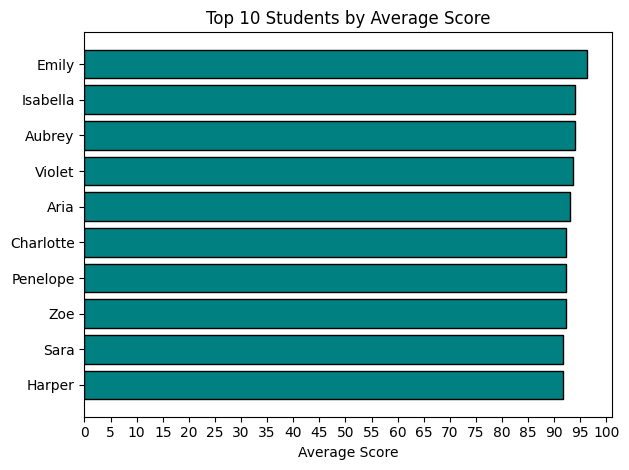

In [42]:
top_students = clean_students_df.sort_values(by='average', ascending=False).head(10)

plt.barh(top_students['name'],
         top_students['average'],
         color='teal',
         edgecolor='black')

plt.title('Top 10 Students by Average Score')
plt.xlabel('Average Score')
plt.xticks(range(0, 101, 5)) 
plt.tight_layout()

plt.gca().invert_yaxis()

plt.show()


##Students at Risk

In [20]:
at_risk = clean_students_df[
    (clean_students_df['average'] >= 65) & (clean_students_df['average'] <= 70)
]

print(f"Total at-risk students: {len(at_risk)}")
at_risk

Total at-risk students: 9


,name,math,science,english,average,grade,math_performance,english_performane,science_performance,best_subject
2,Mike,60.0,70.0,65.0,65.000000,C,Below Average,Below Average,Below Average,science
7,William,70.0,65.0,72.0,69.000000,C,Below Average,Below Average,Below Average,english
11,Benjamin,67.0,72.0,70.0,69.666667,C,Below Average,Below Average,Below Average,science
29,Daniel,65.0,70.0,68.0,67.666667,C,Below Average,Below Average,Below Average,science
40,David,68.0,72.0,66.0,68.666667,C,Below Average,Below Average,Below Average,science
52,Riley,64.0,68.0,65.0,65.666667,C,Below Average,Below Average,Below Average,science
59,Anthony,70.0,72.0,68.0,70.000000,C,Below Average,Below Average,Below Average,science
78,Aaron,67.0,70.0,65.0,67.333333,C,Below Average,Below Average,Below Average,science
84,Charles,65.0,68.0,62.0,65.000000,C,Below Average,Below Average,Below Average,science


##Failed Students

In [21]:
failed_students = clean_students_df[clean_students_df['grade'] == 'F']

failed_percentage = len(failed_students) / len(clean_students_df) * 100

print(f"Failed Percentage : {failed_percentage:.2f}%")

failed_students

Failed Percentage : 17.78%


,name,math,science,english,average,grade,math_performance,english_performane,science_performance,best_subject
3,Nina,45.0,50.0,40.0,45.000000,F,Below Average,Below Average,Below Average,science
9,James,55.0,60.0,58.0,57.666667,F,Below Average,Below Average,Below Average,science
16,Mason,40.0,45.0,38.0,41.000000,F,Below Average,Below Average,Below Average,science
20,Elias,62.0,65.0,60.0,62.333333,F,Below Average,Below Average,Below Average,science
25,Jack,55.0,50.0,52.0,52.333333,F,Below Average,Below Average,Below Average,math
31,Michael,42.0,48.0,45.0,45.000000,F,Below Average,Below Average,Below Average,science
37,Jackson,60.0,65.0,62.0,62.333333,F,Below Average,Below Average,Below Average,science
42,Wyatt,45.0,50.0,48.0,47.666667,F,Below Average,Below Average,Below Average,science
48,Asher,59.0,62.0,60.0,60.333333,F,Below Average,Below Average,Below Average,science
57,Isaac,52.0,55.0,50.0,52.333333,F,Below Average,Below Average,Below Average,science


In [ ]:
clean_students_df.to_csv('data\\cleaned_data.csv', index=False)

---
#Final Insights
---

##Insight

- English recorded the highest average marks among all subjects.

- Student performance in Science was generally stronger compared to Mathematics.

- Emily achieved the highest overall average in the dataset.

- Mathematics showed the lowest average performance, indicating it may be the most challenging subject for students.